In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    XLMRobertaPreTrainedModel,
    XLMRobertaModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput

In [ ]:
def set_up(seed=42):
  set_seed(seed)
  os.environ["PYTHONHASHSEED"] = str(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

In [ ]:
SEED = 42
set_up(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


Xử lý

In [ ]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

In [ ]:
TRAIN_DATASET_PATH = "/content/drive/MyDrive/LegalAI/train_ver3.csv"
VAL_DATASET_PATH = "/content/drive/MyDrive/LegalAI/val_ver3.csv"
TEST_DATASET_PATH = "/content/drive/MyDrive/LegalAI/test_ver3.csv"

In [ ]:
df_train = pd.read_csv(TRAIN_DATASET_PATH)
df_val = pd.read_csv(VAL_DATASET_PATH)
df_test = pd.read_csv(TEST_DATASET_PATH)

In [ ]:
all_classes = sorted(list(set(
    df_train["Class 1"].tolist() + df_train["Class 2"].tolist() +
    df_val["Class 1"].tolist() + df_val["Class 2"].tolist() +
    df_test["Class 1"].tolist() + df_test["Class 2"].tolist()
)))

special_tokens_list = [f"[CLASS_{c}]" for c in all_classes]
class_to_token = {c: f"[CLASS_{c}]" for c in all_classes}
class_to_id = {c: i for i, c in enumerate(all_classes)}
NUM_PRODUCT_CLASSES = len(all_classes)

print(f"Total Product Classes: {NUM_PRODUCT_CLASSES}")
print(f"Sample Special Tokens: {special_tokens_list}")

Total Product Classes: 45
Sample Special Tokens: ['[CLASS_1]', '[CLASS_2]', '[CLASS_3]', '[CLASS_4]', '[CLASS_5]', '[CLASS_6]', '[CLASS_7]', '[CLASS_8]', '[CLASS_9]', '[CLASS_10]', '[CLASS_11]', '[CLASS_12]', '[CLASS_13]', '[CLASS_14]', '[CLASS_15]', '[CLASS_16]', '[CLASS_17]', '[CLASS_18]', '[CLASS_19]', '[CLASS_20]', '[CLASS_21]', '[CLASS_22]', '[CLASS_23]', '[CLASS_24]', '[CLASS_25]', '[CLASS_26]', '[CLASS_27]', '[CLASS_28]', '[CLASS_29]', '[CLASS_30]', '[CLASS_31]', '[CLASS_32]', '[CLASS_33]', '[CLASS_34]', '[CLASS_35]', '[CLASS_36]', '[CLASS_37]', '[CLASS_38]', '[CLASS_39]', '[CLASS_40]', '[CLASS_41]', '[CLASS_42]', '[CLASS_43]', '[CLASS_44]', '[CLASS_45]']


In [ ]:
print(len(df_train), len(df_val), len(df_test))

14945 2137 4267


In [ ]:
nice_class_map = {
    1: "Chemicals, Industry, Science, Photography",
    2: "Paints, Varnishes, Lacquers, Preservatives",
    3: "Cosmetics, Soaps, Perfumery, Cleaning preparations",
    4: "Industrial oils, Greases, Fuels, Candles",
    5: "Pharmaceuticals, Medical, Hygiene, Dietetic food",
    6: "Common metals, Hardware, Metal building materials",
    7: "Machines, Motors, Engines, Tools",
    8: "Hand tools, Cutlery, Side arms, Razors",
    9: "Electronics, Computers, Software, Scientific instruments, Mobile phones",
    10: "Medical devices, Surgical instruments, Orthopedic",
    11: "Lighting, Heating, Cooling, Cooking appliances",
    12: "Vehicles, Transport apparatus, Cars, Bikes",
    13: "Firearms, Ammunition, Explosives",
    14: "Jewelry, Watches, Precious metals, Gemstones",
    15: "Musical instruments",
    16: "Paper, Printed matter, Stationery, Office requisites",
    17: "Rubber, Plastics, Insulation materials",
    18: "Leather, Bags, Wallets, Umbrellas",
    19: "Building materials (Non-metallic), Asphalt, Cement",
    20: "Furniture, Mirrors, Picture frames",
    21: "Household utensils, Kitchenware, Glassware, Combs",
    22: "Ropes, Strings, Nets, Tents, Sacks",
    23: "Yarns, Threads for textile",
    24: "Textiles, Bed covers, Table covers, Fabrics",
    25: "Clothing, Footwear, Headgear, Fashion",
    26: "Lace, Embroidery, Ribbons, Buttons",
    27: "Carpets, Rugs, Mats, Floor coverings",
    28: "Games, Toys, Sports equipment",
    29: "Meat, Fish, Poultry, Processed fruits & vegetables",
    30: "Coffee, Tea, Bread, Rice, Sweets, Spices",
    31: "Agricultural products, Fresh fruits, Vegetables, Seeds",
    32: "Beers, Mineral waters, Non-alcoholic drinks",
    33: "Alcoholic beverages (except beer), Wines, Spirits",
    34: "Tobacco, Smokers' articles, Matches",

    35: "Advertising, Business management, Retail services, Marketing",
    36: "Insurance, Financial affairs, Real estate, Banking",
    37: "Building construction, Repair, Installation services",
    38: "Telecommunications, Broadcasting",
    39: "Transport, Packaging, Storage of goods, Travel",
    40: "Treatment of materials, Recycling, Manufacturing services",
    41: "Education, Training, Entertainment, Sporting activities",
    42: "Technology services, Software development, IT consulting",
    43: "Food and drink services, Restaurants, Hotels",
    44: "Medical services, Hygiene, Beauty care (Spa/Salon)",
    45: "Legal services, Security services, Social services"
}

In [ ]:
MODEL_NAME = 'BAAI/bge-reranker-v2-m3'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def create_dataset(df):
    new_rows = []
    mask_token = tokenizer.mask_token

    for _, row in df.iterrows():
        c1, t1 = row["Class 1"], row["Term 1"]
        c2, t2 = row["Class 2"], row["Term 2"]
        label = row["Similarity"]

        text1_a = f"{mask_token} {t1}"
        text2_a = f"{class_to_token.get(c2, '')} {t2}"
        label_aux_a = class_to_id.get(c1, 0)

        new_rows.append({
            "text1": text1_a, "text2": text2_a,
            "labels": label, "aux_labels": label_aux_a
        })

        text1_b = f"{class_to_token.get(c1, '')} {t1}"
        text2_b = f"{mask_token} {t2}"
        label_aux_b = class_to_id.get(c2, 0)

        new_rows.append({
            "text1": text1_b, "text2": text2_b,
            "labels": label, "aux_labels": label_aux_b
        })

    return pd.DataFrame(new_rows)

In [ ]:
def create_structured_text_enhanced(term, nature, purpose, class_id):
  text = str(term).strip()
  context_parts = []
  if nature and str(nature).strip():
    context_parts.append(f"Nature: {str(nature).strip()}")
  if purpose and str(purpose).strip():
    context_parts.append(f"Use: {str(purpose).strip()}")
  if class_id:
    try:
      c_id = int(str(class_id))
      class_desc = nice_class_map.get(c_id, "")
      if class_desc:
        context_parts.append(f"Category: {class_desc}")
    except:
      pass
  if context_parts:
    full_text = f"{text} [ {' | '.join(context_parts)} ]"
  else:
    full_text = text
  return full_text

In [ ]:
def preprocess(df):
  label_mapping = {
    'Dissimilar': 0,
    'Low similar': 1,
    'Similar': 2,
    'High similar': 3,
    'Identical': 4
  }
  df['label_score'] = df['Similarity'].map(label_mapping)
  df = df.dropna(subset=['label_score'])
  df['label_score'] = df['label_score'].astype(int)

  df['input_text_1'] = df.apply(
      lambda x: create_structured_text_enhanced(x['Term 1'], x['Nature 1'], x['Purpose 1'], x['Class 1']),
      axis=1
  )

  df['input_text_2'] = df.apply(
      lambda x: create_structured_text_enhanced(x['Term 2'], x['Nature 2'], x['Purpose 2'], x['Class 2']),
      axis=1
  )
  return df

In [ ]:
df_train = preprocess(df_train)
df_val = preprocess(df_val)
df_test = preprocess(df_test)

In [ ]:
df_train['label_score'].value_counts().sort_index()

,count
label_score,
0,8261
1,565
2,1905
3,273
4,3941


In [ ]:
df_train.head()

,Unnamed: 0,Pair ID,Term 1,Nature 1,Purpose 1,Class 1,Term 2,Nature 2,Purpose 2,Class 2,Similarity,label_score,input_text_1,input_text_2
0,0,0015146-0007836,business administration,professional organizational and managerial ser...,"managing and overseeing the operations, resour...",35,entertainment services,services,"providing amusement, recreation, or diversion ...",41,Dissimilar,0,business administration [ Nature: professional...,entertainment services [ Nature: services | Us...
1,1,0015146-0058633,business administration,professional organizational and managerial ser...,"managing and overseeing the operations, resour...",35,organisation of trips,service,planning and managing trips for individuals or...,39,Dissimilar,0,business administration [ Nature: professional...,organisation of trips [ Nature: service | Use:...
2,2,0046364-0067216,clothing,garments and articles of dress,covering and adorning the human body,25,long johns,undergarments,providing warmth to the entire lower and somet...,25,Identical,4,clothing [ Nature: garments and articles of dr...,long johns [ Nature: undergarments | Use: prov...
3,3,0073918-0047848,scientific and laboratory devices for treatmen...,electrical apparatus and instruments,administering electrical treatment or performi...,9,decoration and art materials and media,"various physical supplies and substances, incl...","creating artistic works, crafting, and decorat...",16,Dissimilar,0,scientific and laboratory devices for treatmen...,decoration and art materials and media [ Natur...
4,4,0047026-0031233,tea,edible plant product,brewing a beverage for consumption,30,tea essences,concentrated liquid food flavoring,imparting tea flavor to food products or bever...,30,Low similar,1,tea [ Nature: edible plant product | Use: brew...,tea essences [ Nature: concentrated liquid foo...


In [ ]:
df_0 = df_train[df_train['label_score'] == 0]
df_1 = df_train[df_train['label_score'] == 1]
df_2 = df_train[df_train['label_score'] == 2]
df_3 = df_train[df_train['label_score'] == 3]
df_4 = df_train[df_train['label_score'] == 4]

In [ ]:
TARGET_SAMPLES = 3000
MAX_SAMPLES_CLASS_0 = 4500

In [ ]:
def calculate_jaccard(text1, text2):
    set1 = set(str(text1).lower().split())
    set2 = set(str(text2).lower().split())
    if len(set1) == 0 or len(set2) == 0: return 0.0
    intersection = len(set1.intersection(set2))
    union = len(set1) + len(set2) - intersection
    return intersection / union

In [ ]:
df_0['jaccard'] = df_0.apply(lambda x: calculate_jaccard(x['Term 1'], x['Term 2']), axis=1)

/tmp/ipython-input-44413/2748097805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['jaccard'] = df_0.apply(lambda x: calculate_jaccard(x['Term 1'], x['Term 2']), axis=1)


In [ ]:
df_0.head()

,Unnamed: 0,Pair ID,Term 1,Nature 1,Purpose 1,Class 1,Term 2,Nature 2,Purpose 2,Class 2,Similarity,label_score,input_text_1,input_text_2,jaccard
0,0,0015146-0007836,business administration,professional organizational and managerial ser...,"managing and overseeing the operations, resour...",35,entertainment services,services,"providing amusement, recreation, or diversion ...",41,Dissimilar,0,business administration [ Nature: professional...,entertainment services [ Nature: services | Us...,0.000000
1,1,0015146-0058633,business administration,professional organizational and managerial ser...,"managing and overseeing the operations, resour...",35,organisation of trips,service,planning and managing trips for individuals or...,39,Dissimilar,0,business administration [ Nature: professional...,organisation of trips [ Nature: service | Use:...,0.000000
3,3,0073918-0047848,scientific and laboratory devices for treatmen...,electrical apparatus and instruments,administering electrical treatment or performi...,9,decoration and art materials and media,"various physical supplies and substances, incl...","creating artistic works, crafting, and decorat...",16,Dissimilar,0,scientific and laboratory devices for treatmen...,decoration and art materials and media [ Natur...,0.083333
5,5,0016148-0033523,wine,alcoholic beverage,for consumption as an alcoholic drink,33,cream liqueurs,sweet alcoholic beverages,"consumption as an alcoholic beverage, often as...",33,Dissimilar,0,wine [ Nature: alcoholic beverage | Use: for c...,cream liqueurs [ Nature: sweet alcoholic bever...,0.000000
6,6,0009379-0019852,make-up removing appliances,non-electrical manual tools; cloths or pads,facilitating the removal of make-up from the s...,21,sound reproduction apparatus,electronic apparatus,playing back recorded audio,9,Dissimilar,0,make-up removing appliances [ Nature: non-elec...,sound reproduction apparatus [ Nature: electro...,0.000000


In [ ]:
hard_negatives = df_0[df_0['jaccard'] > 0]
easy_negatives = df_0[df_0['jaccard'] == 0]
print(len(hard_negatives))
print(len(easy_negatives))

1395
6866


In [ ]:
n_easy_keep = max(0, MAX_SAMPLES_CLASS_0 - len(hard_negatives))
if len(easy_negatives) > n_easy_keep:
    easy_negatives_sampled = resample(easy_negatives, replace=False, n_samples=n_easy_keep, random_state=42)
else:
    easy_negatives_sampled = easy_negatives

In [ ]:
df_0_final = pd.concat([hard_negatives, easy_negatives_sampled])

In [ ]:
df_0_final = resample(df_0_final, replace=False, n_samples=MAX_SAMPLES_CLASS_0, random_state=42)

In [ ]:
df_train.head()

,Unnamed: 0,Pair ID,Term 1,Nature 1,Purpose 1,Class 1,Term 2,Nature 2,Purpose 2,Class 2,Similarity,label_score,input_text_1,input_text_2
0,0,0015146-0007836,business administration,professional organizational and managerial ser...,"managing and overseeing the operations, resour...",35,entertainment services,services,"providing amusement, recreation, or diversion ...",41,Dissimilar,0,business administration [ Nature: professional...,entertainment services [ Nature: services | Us...
1,1,0015146-0058633,business administration,professional organizational and managerial ser...,"managing and overseeing the operations, resour...",35,organisation of trips,service,planning and managing trips for individuals or...,39,Dissimilar,0,business administration [ Nature: professional...,organisation of trips [ Nature: service | Use:...
2,2,0046364-0067216,clothing,garments and articles of dress,covering and adorning the human body,25,long johns,undergarments,providing warmth to the entire lower and somet...,25,Identical,4,clothing [ Nature: garments and articles of dr...,long johns [ Nature: undergarments | Use: prov...
3,3,0073918-0047848,scientific and laboratory devices for treatmen...,electrical apparatus and instruments,administering electrical treatment or performi...,9,decoration and art materials and media,"various physical supplies and substances, incl...","creating artistic works, crafting, and decorat...",16,Dissimilar,0,scientific and laboratory devices for treatmen...,decoration and art materials and media [ Natur...
4,4,0047026-0031233,tea,edible plant product,brewing a beverage for consumption,30,tea essences,concentrated liquid food flavoring,imparting tea flavor to food products or bever...,30,Low similar,1,tea [ Nature: edible plant product | Use: brew...,tea essences [ Nature: concentrated liquid foo...


In [ ]:
def augment_and_balance(df_sub, target_count):
    # Đảo chiều (Symmetry) - A vs B thành B vs A
    df_flipped = df_sub.copy()
    df_flipped['input_text_1'] = df_sub['input_text_2']
    df_flipped['input_text_2'] = df_sub['input_text_1']

    df_aug = pd.concat([df_sub, df_flipped])

    current_count = len(df_aug)
    if current_count < target_count:
        df_final = resample(df_aug, replace=True, n_samples=target_count, random_state=42)
    elif current_count > target_count:
        df_final = resample(df_aug, replace=False, n_samples=target_count, random_state=42)
    else:
        df_final = df_aug

    return df_final

In [ ]:
def augment_cross_pairing(df_input, target_labels=[3, 4]):
      # A , B high similar/ identical, B , C : high similar/ identical => A/C : high similar/identical
      df = df_input.copy()
      df['key_1'] = df['Class 1'].astype(str) + " | " + df['Term 1'].astype(str)
      df['key_2'] = df['Class 2'].astype(str) + " | " + df['Term 1'].astype(str)
      high_quality_df = df[df['label_score'].isin(target_labels)].copy()

      forward = high_quality_df[['key_1', 'key_2', 'label_score', 'Class 2', 'Term 2']].rename(
          columns={'key_1': 'parent', 'key_2': 'child', 'label_score': 'score', 'Class 2': 'class_child', 'Term 2': 'term_child'}
        )
      backward = high_quality_df[['key_2', 'key_1', 'label_score', 'Class 1', 'Term 1']].rename(
          columns={'key_2': 'parent', 'key_1': 'child', 'label_score': 'score', 'Class 1': 'class_child', 'Term 1': 'term_child'}
        )
      connections = pd.concat([forward, backward])

      # Tìm các cặp (Child 1, Child 2) có chung parent
      merged = pd.merge(connections, connections, on='parent', suffixes=('_1', '_2'))
      new_pairs = merged[merged['child_1'] < merged['child_2']].copy()
      if len(new_pairs) == 0:
        return df_input
        # Lấy nhãn min : A - B: 4, B - C: 3 => A - C: 3
      new_pairs['label_score'] = new_pairs[['score_1', 'score_2']].min(axis=1)

      df_aug = pd.DataFrame({
            "Class 1": new_pairs["class_child_1"],
            "Term 1": new_pairs["term_child_1"],
            "Class 2": new_pairs['class_child_2'],
            "Term 2": new_pairs['term_child_2'],
            "label_score": new_pairs["label_score"],
            "input_text_1": new_pairs['class_child_1'].astype(str) + ": " + new_pairs['term_child_1'].astype(str),
            "input_text_2": new_pairs['class_child_2'].astype(str) + ": " + new_pairs['term_child_2'].astype(str)
        })

        # Loại bỏ trùng
      existing_pairs = set(df['key_1'] + "_" + df['key_2']) | set(df['key_2'] + "_" + df['key_1'])
      df_aug['pair_id'] = df_aug['Class 1'].astype(str) + " | " + df_aug['Term 1'].astype(str) + "_" + \
                          df_aug['Class 2'].astype(str) + " | " + df_aug['Term 2'].astype(str)
      df_aug = df_aug[~df_aug['pair_id'].isin(existing_pairs)]
      df_aug = df_aug.drop(columns=['pair_id'])
      print(f"Number of cross_pairing: {len(df_aug)}")
      return pd.concat([df_input, df_aug], ignore_index=True)

Number of cross_pairing: 588

KẾT QUẢ EDA DỮ LIỆU CROSS-PAIRING
1. SỐ LƯỢNG:
- Gốc: 14945 cặp
- Mới: 588 cặp
- Tăng trưởng: +3.93%


/tmp/ipython-input-44413/188186252.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_score', data=df_new_only, palette='viridis')


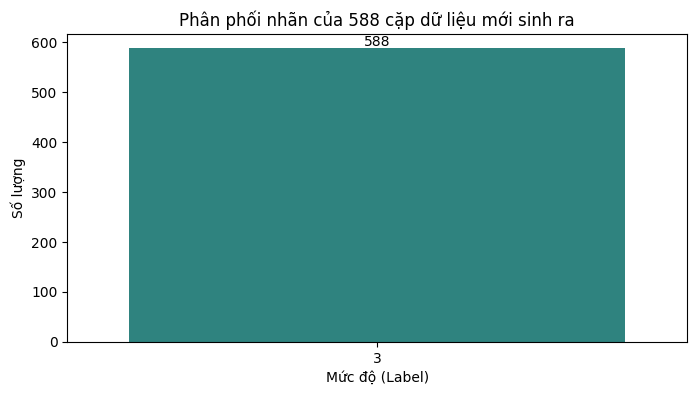

--------------------------------------------------------------------------------
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] girls' clothing
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] clothing for fishermen
Mức 3 | [24] towels of textile  <--->  [25] gloves including those made of skin, hide or fur
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] sweat bands for the wrist
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] athletic uniforms
--------------------------------------------------------------------------------
- Số cặp bị trùng lặp trong phần mới: 291


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df_aug_full = augment_cross_pairing(df_train)

num_original = len(df_train)
num_total = len(df_aug_full)
num_new = num_total - num_original

if num_new == 0:
    print("Không sinh ra được cặp nào mới! (Có thể do dữ liệu gốc ít cặp Mức 3/4 quá)")
else:
    df_new_only = df_aug_full.iloc[num_original:].copy()

    print(f"\n{'='*40}")
    print(f"KẾT QUẢ EDA DỮ LIỆU CROSS-PAIRING")
    print(f"{'='*40}")
    print(f"1. SỐ LƯỢNG:")
    print(f"- Gốc: {num_original} cặp")
    print(f"- Mới: {num_new} cặp")
    print(f"- Tăng trưởng: +{num_new/num_original*100:.2f}%")

    plt.figure(figsize=(8, 4))
    ax = sns.countplot(x='label_score', data=df_new_only, palette='viridis')
    plt.title(f'Phân phối nhãn của {num_new} cặp dữ liệu mới sinh ra')
    plt.xlabel('Mức độ (Label)')
    plt.ylabel('Số lượng')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.show()

    # In ra 10 cặp ngẫu nhiên
    print("-" * 80)
    sample_new = df_new_only.sample(min(10, len(df_new_only)), random_state=42)

    for idx, row in sample_new.iterrows():
        print(f"Mức {row['label_score']} | [{row['Class 1']}] {row['Term 1']}  <--->  [{row['Class 2']}] {row['Term 2']}")

    print("-" * 80)

    # Kiểm tra xem trong đám mới sinh ra có bị trùng nhau không
    duplicates = df_new_only.duplicated(subset=['input_text_1', 'input_text_2']).sum()
    print(f"- Số cặp bị trùng lặp trong phần mới: {duplicates}")

In [ ]:

def process_and_create_dataset(df, tokenizer, class_to_token, class_to_id, nice_class_map):
    # 1. Mapping nhãn Similarity sang dạng số (0 -> 4)
    label_mapping = {
        'Dissimilar': 0,
        'Low similar': 1,
        'Similar': 2,
        'High similar': 3,
        'Identical': 4
    }

    mask_token = tokenizer.mask_token
    new_rows = []

    def build_context(nature, purpose, class_id):
        parts = []
        if pd.notna(nature) and str(nature).strip():
            parts.append(f"Nature: {str(nature).strip()}")
        if pd.notna(purpose) and str(purpose).strip():
            parts.append(f"Use: {str(purpose).strip()}")
        if pd.notna(class_id):
            try:
                c_id = int(str(class_id))
                class_desc = nice_class_map.get(c_id, "")
                if class_desc:
                    parts.append(f"Category: {class_desc}")
            except ValueError:
                pass

        return f" [ {' | '.join(parts)} ]" if parts else ""

    for _, row in df.iterrows():

        label_score = row.get('label_score')

        c1 = row.get("Class 1")
        base_t1 = str(row.get("Term 1", "")).strip() + build_context(
            row.get("Nature 1"), row.get("Purpose 1"), c1
        )

        c2 = row.get("Class 2")
        base_t2 = str(row.get("Term 2", "")).strip() + build_context(
            row.get("Nature 2"), row.get("Purpose 2"), c2
        )

        text1_a = f"{mask_token} {base_t1}"
        text2_a = f"{class_to_token.get(c1, '')} {base_t2}".strip() # Hoặc dùng get(c2, '') tùy logic cũ của bạn

        new_rows.append({
            "text1": text1_a,
            "text2": text2_a,
            "labels": label_score,
            "aux_labels": class_to_id.get(c1, 0)
        })

        text1_b = f"{class_to_token.get(c1, '')} {base_t1}".strip()
        text2_b = f"{mask_token} {base_t2}"

        new_rows.append({
            "text1": text1_b,
            "text2": text2_b,
            "labels": label_score,
            "aux_labels": class_to_id.get(c2, 0)
        })

    return pd.DataFrame(new_rows)

In [ ]:
df_aug_clean = df_aug_full.drop_duplicates(subset=['input_text_1', 'input_text_2'], keep='first')
len(df_aug_clean)

15242

In [ ]:
df_train = df_aug_clean.copy()
len(df_train)

15242

In [ ]:
df_1_final = augment_and_balance(df_train[df_train['label_score'] == 1], TARGET_SAMPLES) # Lớp 1 (Thiếu)
df_3_final = augment_and_balance(df_train[df_train['label_score'] == 3], TARGET_SAMPLES) # Lớp 3 (Rất thiếu)

In [ ]:
df_2_sub = df_train[df_train['label_score'] == 2]
df_2_final = resample(df_2_sub, replace=(len(df_2_sub) < TARGET_SAMPLES), n_samples=TARGET_SAMPLES, random_state=42)

df_4_sub = df_train[df_train['label_score'] == 4]
df_4_final = resample(df_4_sub, replace=False, n_samples=TARGET_SAMPLES, random_state=42)

In [ ]:
df_train_balanced = pd.concat([df_0_final, df_1_final, df_2_final, df_3_final, df_4_final])
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle

In [ ]:
duplicates = df_train_balanced.duplicated(subset=['input_text_1', 'input_text_2']).sum()
print(f"- Số cặp bị trùng lặp trong phần mới: {duplicates}")

- Số cặp bị trùng lặp trong phần mới: 5472


In [ ]:
print(df_train_balanced['label_score'].value_counts().sort_index())

label_score
0    4500
1    3000
2    3000
3    3000
4    3000
Name: count, dtype: int64


In [ ]:
df_train_aug = process_and_create_dataset(df_train_balanced, tokenizer=tokenizer,class_to_token=class_to_token, class_to_id=class_to_id, nice_class_map=nice_class_map )
df_val_aug = process_and_create_dataset(df_val, tokenizer=tokenizer,class_to_token=class_to_token, class_to_id=class_to_id, nice_class_map=nice_class_map )
df_test_aug = process_and_create_dataset(df_test, tokenizer=tokenizer,class_to_token=class_to_token, class_to_id=class_to_id, nice_class_map=nice_class_map )

In [ ]:
duplicates = df_train_aug.drop_duplicates(subset=['text1', 'text2']).sum()

In [ ]:
print(len(duplicates))

4


In [ ]:
len(df_train_aug), len(df_val_aug), len(df_test_aug)

(33000, 4274, 8534)

In [ ]:
print(df_train_aug['labels'].value_counts().sort_index())

labels
0    9000
1    6000
2    6000
3    6000
4    6000
Name: count, dtype: int64


In [ ]:
print(df_val_aug['labels'].value_counts().sort_index())

labels
0    2360
1     164
2     544
3      78
4    1128
Name: count, dtype: int64


In [ ]:
print(df_test_aug['labels'].value_counts().sort_index())

labels
0    4720
1     322
2    1088
3     154
4    2250
Name: count, dtype: int64


In [ ]:
def preprocess_dataset(examples):
    tokenized = tokenizer(
        examples["text1"],
        examples["text2"],
        truncation=True,
        max_length=64,
        padding=False
    )
    tokenized["labels"] = examples["labels"]
    tokenized["aux_labels"] = examples["aux_labels"]
    return tokenized

In [ ]:
cols_to_remove = df_train_aug.columns.tolist()

train_ds = Dataset.from_pandas(df_train_aug).map(
    preprocess_dataset,
    batched=True,
    remove_columns=cols_to_remove
)

val_ds = Dataset.from_pandas(df_val_aug).map(
    preprocess_dataset,
    batched=True,
    remove_columns=df_val_aug.columns.tolist()
)

test_ds = Dataset.from_pandas(df_test_aug).map(
    preprocess_dataset,
    batched=True,
    remove_columns=df_test_aug.columns.tolist()
)
cols = ["input_ids", "attention_mask", "labels", "aux_labels"]
for ds in [train_ds, val_ds, test_ds]:
    ds.set_format(type="torch", columns=cols)

Map:   0%|          | 0/33000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4274 [00:00<?, ? examples/s]

Map:   0%|          | 0/8534 [00:00<?, ? examples/s]

In [ ]:
train_ds[0]

{'labels': tensor(0),
 'aux_labels': tensor(2),
 'input_ids': tensor([     0, 250001,  13492,  33059,  24709,      7,    378,  58806,     12,
         165045, 212485,      7,     23,  24709,   3173,      6,  58745,  36836,
             12,  59911,    214,     10, 158618,    707, 156100,  67229,     47,
          71579,      7,      6,  58745,      2,    378,  37486,  70877,    454,
          96386,  24887,    459,   5256,    378,  58806,     12,    351,      9,
         167455,  27686, 102942, 212485,      7,      6,  58745,  36836,     12,
            100,  38415,     47,     70,  24887,    100, 102942,  60042,      7,
              2]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}

Run Model

In [ ]:
df_train_aug['labels'].unique()

array([0, 1, 2, 3, 4])

In [ ]:
import numpy as np
import torch
from torch import nn
from sklearn.utils import resample, class_weight
from sentence_transformers import CrossEncoder, InputExample, losses
from torch.utils.data import DataLoader
from sentence_transformers.cross_encoder.evaluation import CESoftmaxAccuracyEvaluator
from transformers import AutoTokenizer

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoConfig,
    XLMRobertaPreTrainedModel,
    XLMRobertaModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RankAwareFocalLoss(nn.Module):
    def __init__(self, num_classes=5, gamma=2.0, alpha=0.5):
        super(RankAwareFocalLoss, self).__init__()
        self.num_classes = num_classes
        self.gamma = gamma
        self.alpha = alpha
        self.register_buffer('rank_values', torch.arange(num_classes).float())

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        focal_loss = focal_loss.mean()
        probs = F.softmax(logits, dim=-1)

        rank_values = self.rank_values.to(logits.device)
        expected_ranks = torch.sum(probs * rank_values, dim=-1)

        rank_loss = F.mse_loss(expected_ranks, targets.float())
        total_loss = focal_loss + (self.alpha * rank_loss)

        return total_loss

In [ ]:
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn

class JointClassSimBGE(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.alpha = getattr(config, "alpha", 0.5)
        self.aux_weight = getattr(config, "aux_weight", 0.3)
        self.num_labels = 5
        self.num_product_classes = config.num_product_classes

        self.mask_token_id = getattr(config, "mask_token_id", 250001)

        self.roberta = XLMRobertaModel(config)
        self.classifier = nn.Linear(config.hidden_size, self.num_labels)
        self.aux_classifier = nn.Linear(config.hidden_size, self.num_product_classes)

        self.register_buffer("class_weights", None)

        if getattr(config, "gradient_checkpointing", False):
            self.roberta.gradient_checkpointing = True
            self.roberta.config.use_cache = False

        self.loss_fct_sim = RankAwareFocalLoss(num_classes=self.num_labels, gamma=2.0, alpha=self.alpha)
        self.loss_fct_aux = nn.CrossEntropyLoss()

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, aux_labels=None,
                num_items_in_batch=None,
                **kwargs):

        outputs = self.roberta(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, **kwargs)

        cls_output = outputs.last_hidden_state[:, 0, :]
        logits_sim = self.classifier(cls_output)

        is_mask_token = (input_ids == self.mask_token_id).int()
        mask_positions = is_mask_token.argmax(dim=-1)

        batch_size = input_ids.size(0)
        batch_indices = torch.arange(batch_size, device=input_ids.device)
        mask_output = outputs.last_hidden_state[batch_indices, mask_positions, :]

        logits_aux = self.aux_classifier(mask_output)

        loss = None
        if labels is not None:
            loss_sim = self.loss_fct_sim(logits_sim.view(-1, self.num_labels), labels.view(-1))

            loss_aux = torch.tensor(0.0, device=logits_sim.device)

            if aux_labels is not None and self.training:
                loss_aux = self.loss_fct_aux(logits_aux.view(-1, self.num_product_classes), aux_labels.view(-1))

            loss = loss_sim + (self.aux_weight * loss_aux)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits_sim
        )

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(df_train_balanced["label_score"]),
    y=df_train_balanced["label_score"]
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"Class Weights: {class_weights_tensor}")

Class Weights: tensor([0.7333, 1.1000, 1.1000, 1.1000, 1.1000], device='cuda:0')


In [ ]:
import sys
sys.modules['__main__'].__file__ = 'dummy_notebook_file.py'

In [ ]:
from transformers import AutoConfig

def model_init(trial):
    config = AutoConfig.from_pretrained(MODEL_NAME)
    config.num_labels = 5
    config.num_product_classes = NUM_PRODUCT_CLASSES
    config.mask_token_id = tokenizer.mask_token_id

    if trial is not None:
        config.alpha = trial.suggest_float("alpha", 0.05, 1.0, log=True)
        config.aux_weight = trial.suggest_float("aux_weight", 0.1, 0.5)
    else:
        config.alpha = 0.5
        config.aux_weight = 0.3

    # 3. Trả về model với config mới
    model = JointClassSimBGE.from_pretrained(MODEL_NAME, config=config, ignore_mismatched_sizes=True)
    model.resize_token_embeddings(len(tokenizer))
    return model

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(labels, tuple):
        labels = labels[0]

    if isinstance(logits, tuple):
        logits = logits[0]

    preds = np.argmax(logits, axis=-1)
    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    mae = mean_absolute_error(labels, preds)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "qwk": qwk,
        "mae": mae
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./bge_joint_class_sim",
    learning_rate=1.5e-5,
    weight_decay=0.01,
    num_train_epochs=10,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    dataloader_num_workers=2,
    per_device_eval_batch_size=16,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=10,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="qwk",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    data_seed=SEED,
    remove_unused_columns=False
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
best_trial.hyperparameters

NameError: name 'best_trial' is not defined

In [ ]:
!rm -rf ./bge_joint_class_sim_final_safe
!rm -rf ./bge_joint_class_sim_final

In [ ]:
BASE_MODEL = "BAAI/bge-reranker-v2-m3"
best_params = {
    'learning_rate': 2.0984241735531933e-5,
    'weight_decay': 0.024443842876227084,
    'alpha': 0.4705510739166728,
    'aux_weight': 0.25979712263230104
}
config_final = AutoConfig.from_pretrained(BASE_MODEL)
config_final.num_labels = 5
config_final.num_product_classes = NUM_PRODUCT_CLASSES
config_final.mask_token_id = tokenizer.mask_token_id
config_final.alpha = best_params['alpha']
config_final.aux_weight = best_params['aux_weight']

final_model = JointClassSimBGE.from_pretrained(
    BASE_MODEL,
    config=config_final,
    ignore_mismatched_sizes=True
)
final_model.resize_token_embeddings(len(tokenizer))
training_args = TrainingArguments(
    output_dir="./bge_joint_class_sim_final",
    learning_rate=best_params['learning_rate'],
    weight_decay=best_params['weight_decay'],
    num_train_epochs=10,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,

    gradient_checkpointing=False,

    dataloader_num_workers=2,
    per_device_eval_batch_size=16,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=10,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="qwk",
    greater_is_better=True,

    bf16=True,
    fp16=False,
    tf32=True,

    seed=SEED,
    data_seed=SEED,
    remove_unused_columns=False
)

Đang nạp lại tạ (weights) gốc sạch sẽ từ Hugging Face...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

JointClassSimBGE LOAD REPORT from: BAAI/bge-reranker-v2-m3
Key                         | Status     | 
----------------------------+------------+-
classifier.out_proj.bias    | UNEXPECTED | 
classifier.dense.bias       | UNEXPECTED | 
classifier.dense.weight     | UNEXPECTED | 
classifier.out_proj.weight  | UNEXPECTED | 
classifier.bias             | MISSING    | 
roberta.pooler.dense.weight | MISSING    | 
loss_fct_sim.rank_values    | MISSING    | 
aux_classifier.bias         | MISSING    | 
classifier.weight           | MISSING    | 
aux_classifier.weight       | MISSING    | 
roberta.pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
final_trainer = Trainer(
    model=final_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

print("Bắt đầu Training chốt hạ...")
final_trainer.train()

Bắt đầu Training chốt hạ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Qwk,Mae
1,11.289921,2.570646,0.833177,0.664638,0.884705,0.301357
2,10.153869,2.552891,0.880674,0.756132,0.913409,0.224146
3,9.592914,2.612773,0.881610,0.770714,0.918309,0.220402
4,9.563450,2.674359,0.894010,0.787415,0.922002,0.201919
5,10.147943,2.750034,0.892139,0.787565,0.923926,0.202387
6,9.574609,2.729227,0.909686,0.812568,0.932864,0.173140
7,8.964253,2.747453,0.907815,0.814780,0.932484,0.176182
8,10.416970,2.756926,0.910154,0.814619,0.937286,0.167759
9,11.828555,2.759202,0.910388,0.814443,0.938019,0.166589
10,9.752222,2.758069,0.909453,0.812872,0.937252,0.168694


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=10320, training_loss=10.729915902780933, metrics={'train_runtime': 3699.295, 'train_samples_per_second': 89.206, 'train_steps_per_second': 2.79, 'total_flos': 3.844840336128e+16, 'train_loss': 10.729915902780933, 'epoch': 10.0})

In [ ]:
test_output = final_trainer.predict(test_ds)
predictions = test_output.predictions

if isinstance(predictions, tuple):
    predictions = predictions[0]

reshaped_logits = predictions.reshape(-1, 2, 5)
avg_logits = reshaped_logits.mean(axis=1)

test_preds = np.argmax(avg_logits, axis=-1)
test_true = df_test["label_score"].values

In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
def safe_div(a, b):
    return float(a) / float(b) if b else 0.0

def main(df):
    y_true = df["label"].to_numpy()
    y_pred = df["pred"].to_numpy()

    labels = list(range(5))
    label_names = ['Dissimilar (0)', 'Low (1)', 'Similar (2)', 'High (3)', 'Identical (4)']
    K = len(labels)
    idx = {c: i for i, c in enumerate(labels)}

    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if t in idx and p in idx:
            cm[idx[t], idx[p]] += 1

    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (TP + FP + FN)

    per_class = []
    for i, c in enumerate(labels):
        support = cm[i, :].sum()
        precision = safe_div(TP[i], TP[i] + FP[i])
        recall = safe_div(TP[i], TP[i] + FN[i])
        f1 = safe_div(2 * precision * recall, precision + recall)
        acc = safe_div(TP[i] + TN[i], TP[i] + TN[i] + FP[i] + FN[i])
        per_class.append({
            "class": c,
            "support": int(support),
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    TP_micro = TP.sum()
    FP_micro = FP.sum()
    FN_micro = FN.sum()

    micro_precision = safe_div(TP_micro, TP_micro + FP_micro)
    micro_recall = safe_div(TP_micro, TP_micro + FN_micro)
    micro_f1 = safe_div(2 * micro_precision * micro_recall, micro_precision + micro_recall)

    macro_precision = np.mean([r["precision"] for r in per_class])
    macro_recall = np.mean([r["recall"] for r in per_class])
    macro_f1 = np.mean([r["f1"] for r in per_class])

    overall_acc = safe_div((y_true == y_pred).sum(), len(y_true))

    mae = np.mean(np.abs(y_true - y_pred))
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    print("Per-class metrics (class | support | accuracy | precision | recall | f1):")
    for r in per_class:
        print(f"{r['class']:>2} | {r['support']:>6} | {r['accuracy']:.4f} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1']:.4f}")

    print("\nOverall accuracy:", f"{overall_acc:.4f}")
    print("Micro Precision | Recall | F1:", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}")
    print("Macro Precision | Recall | F1:", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}")

    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")

    print("\nConfusion Matrix (Hàng = Thực tế, Cột = Dự đoán):")
    header = "    " + "".join([f" P{c:>3}" for c in labels])
    print(header)
    print("   " + "-" * len(header))
    for i, row in enumerate(cm):
        print(f"T{labels[i]} |" + "".join([f"{val:>4}" for val in row]))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)

    plt.savefig('confusion_matrix.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('confusion_matrix.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()
    return overall_acc, mae, qwk

In [ ]:
result_df = pd.DataFrame({
    "label": test_true,
    "pred": test_preds,
})

Per-class metrics (class | support | accuracy | precision | recall | f1):
 0 |   2360 | 0.9475 | 0.9660 | 0.9381 | 0.9518
 1 |    161 | 0.9723 | 0.6080 | 0.7516 | 0.6722
 2 |    544 | 0.9395 | 0.7449 | 0.7996 | 0.7713
 3 |     77 | 0.9883 | 0.6901 | 0.6364 | 0.6622
 4 |   1125 | 0.9616 | 0.9286 | 0.9253 | 0.9270

Overall accuracy: 0.9046
Micro Precision | Recall | F1: 0.9046 0.9046 0.9046
Macro Precision | Recall | F1: 0.7875 0.8102 0.7969
Mean Absolute Error (MAE): 0.1776
Quadratic Weighted Kappa (QWK): 0.9323

Confusion Matrix (Hàng = Thực tế, Cột = Dự đoán):
     P  0 P  1 P  2 P  3 P  4
   -----------------------------
T0 |2214  48  74   5  19
T1 |  24 121  12   0   4
T2 |  37  19 435   8  45
T3 |   3   1  12  49  12
T4 |  14  10  51   91041


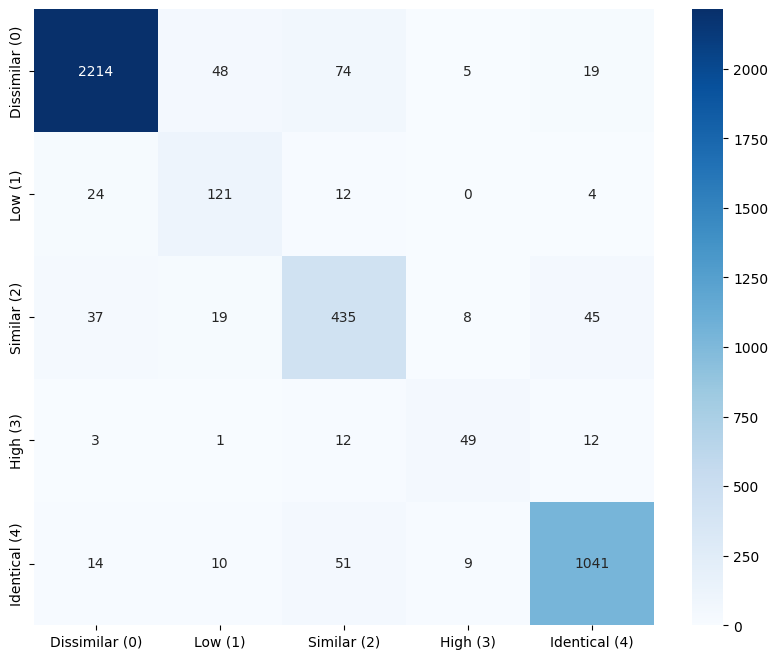

(0.9046168268104054,
 np.float64(0.17764237168971175),
 np.float64(0.9323076816962222))

In [ ]:
main(result_df)